# Project Two Executive Summary

## Mission and Vision Statement Networks in New York City Colleges

This study examines how colleges in New York City frame their mission and vision statements.

Using publicly available college website data, and data from the **[Integrated Postsecondary Education Data System (IPEDS)](https://nces.ed.gov/ipeds)**, we constructed a dataset of NYC college mission and vision statements. The statements were copied and pasted into a Google Sheet and then an API is used to connect the data to the Jupyter Notebook. 

### Model 1: Preparing the Tools

In this section, I loaded the software libraries needed to complete my analysis.

In sum, these tools allow me to:

- Create a dictionary of mission and vision statements for colleges.
- Perform calculations and statistical tests.
- Create visual charts to help interpret results.

Even though some of these libraries are basic and repeatedly used in many projects, such as pandas, I commented out each library to understand their functions.

In [1]:
# Module 1: Import Libraries

import pandas as pd                    # Used to work with tables of data (like Excel sheets in Python)

from google.oauth2.service_account import Credentials  # Used to authenticate and connect to Google Sheets API

import gspread                          # Used to interact with Google Sheets through the API

# import matplotlib.pyplot as plt      # Used to control chart formatting and display plots

from sklearn.feature_extraction.text import TfidfVectorizer  # Used to convert text into numerical features using TF-IDF

import re                              # Used to perform regular expression matching and text manipulation

import networkx as nx                  # Used to create and analyze networks and graphs

### Module 2: Loading the Data

From Google Sheets, we set up an API to directly read in the data. 

In addition to the mission and vision statements, some of the variables contained in this dataset include, but are not limited to:

1. UNITID (A unique identifier for each institution).
2. Institutional Name.
3. Address info included longitude and latitude geodata to potential map institutions.

In [2]:
import gspread
import pandas as pd
from google.oauth2.service_account import Credentials

scope = [
    "https://www.googleapis.com/auth/spreadsheets",
    "https://www.googleapis.com/auth/drive"
]

creds = Credentials.from_service_account_file(
    r"C:\Users\zengo\OneDrive\Magic Briefcase\School of Professional Studies\DATA 620 Web Analytics\Project 2\crucial-zodiac-333018-7db0dfea33da.json",
    scopes=scope
)

client = gspread.authorize(creds)

# ONLY the spreadsheet ID
spreadsheet = client.open_by_key("1nE5HAiaJ1hnqT8L-6V39qtfZdmgrvhg0xJ8USGvzLrk")

worksheet = spreadsheet.get_worksheet(0)

data = worksheet.get_all_records()

college_statements = pd.DataFrame(data)

college_statements.head()


,UNITID,INSTNM,CITY,STABBR,ZIP,LATITUDE,LONGITUD,Mission,Vision
0,188340,Vaughn College of Aeronautics and Technology,Flushing,NY,11369,40.768348,-73.881721,To provide a dynamic learning environment buil...,To change the world one student at a time with...
1,188650,Allen School-Brooklyn,Brooklyn,NY,11201,40.693797,-73.991546,"To provide superior, high-quality, campus-base...",Allen College is a Leading Institution to Enri...
2,188678,American Academy of Dramatic Arts-New York,New York,NY,10016,40.745545,-73.984843,A world-leading acting conservatory and colleg...,The American Academy of Dramatic Arts upholds ...
3,188687,American Academy McAllister Institute of Funer...,New York,NY,10036,40.757105,-73.986466,AAMI exists to: Provide a learning environment...,None
4,188890,Apex Technical School,Long Island City,NY,11101,40.748807,-73.949306,Offer quality hands-on training that provides ...,None


### Data Diagnostics

In Modules 3A-I, we apply various functions to diagnose the data. 

#### Module 3A: Convert all columns to lowercase.

Column capitalization sometimes changes between CSV, Google Sheets, and pandas imports. Therefore, we converted variable names to lowercase.

In [3]:
# Module 3A: Convert all column names to lowercase
college_statements.columns = college_statements.columns.str.lower()

# Check the first few rows to ensure the column names are updated
print(college_statements.head())

   unitid                                             instnm  \
0  188340       Vaughn College of Aeronautics and Technology   
1  188650                              Allen School-Brooklyn   
2  188678         American Academy of Dramatic Arts-New York   
3  188687  American Academy McAllister Institute of Funer...   
4  188890                              Apex Technical School   

               city stabbr    zip   latitude   longitud  \
0          Flushing     NY  11369  40.768348 -73.881721   
1          Brooklyn     NY  11201  40.693797 -73.991546   
2          New York     NY  10016  40.745545 -73.984843   
3          New York     NY  10036  40.757105 -73.986466   
4  Long Island City     NY  11101  40.748807 -73.949306   

                                             mission  \
0  To provide a dynamic learning environment buil...   
1  To provide superior, high-quality, campus-base...   
2  A world-leading acting conservatory and colleg...   
3  AAMI exists to: Provide a learnin

#### Module 3B: Normalize names with Lemmatization.

An issue that we may run into is singular and plural words treated as separate words. We normalize the words through the process of lemmatization so that words like student / students, community / communities, program / programs, etc., are treated as the same word before computing TF-IDF.

This keeps the matrix clean and avoids duplicate columns.

In [4]:
# Module 3B: Normalize Text with Lemmatization

from nltk.stem import WordNetLemmatizer
import re

# Initialize lemmatizer
lemmatizer = WordNetLemmatizer()

def normalize_text(text):
    # Convert the text to lowercase and tokenize
    text = text.lower()
    
    # Use regex to find words (match only alphabetic words)
    words = re.findall(r'\b[a-z]+\b', text)
    
    # Lemmatize words
    normalized = [lemmatizer.lemmatize(w) for w in words]  # Lemmatize the words
    
    # Return the cleaned and normalized text
    return " ".join(normalized)

# Apply the normalization to the mission statements without renaming the column
college_statements["mission"] = college_statements["mission"].apply(normalize_text)

# Check the first few rows of the cleaned mission text
print(college_statements[["instnm", "mission"]].head())

                                              instnm  \
0       Vaughn College of Aeronautics and Technology   
1                              Allen School-Brooklyn   
2         American Academy of Dramatic Arts-New York   
3  American Academy McAllister Institute of Funer...   
4                              Apex Technical School   

                                             mission  
0  to provide a dynamic learning environment buil...  
1  to provide superior high quality campus based ...  
2  a world leading acting conservatory and colleg...  
3  aami exists to provide a learning environment ...  
4  offer quality hand on training that provides y...  


#### Module 3C: Describe the Data

There are 164 institutions in NYC. There are four CUNY schools that do not have an UNITID assigned per IPEDS

In [5]:
college_statements.describe()

,unitid,instnm,city,stabbr,zip,latitude,longitud,mission,vision
count,162,162,162,162,162,162,162,162,162
unique,158,162,21,1,128,156,156,161,33
top,,Vaughn College of Aeronautics and Technology,New York,NY,11219,,,to provide superior high quality campus based ...,
freq,5,1,64,162,5,5,5,2,91


#### Module 3D: Identify which columns have duplicates.

Rows 42-45 have duplicated UNITIDs (no entry).

In [6]:
for col in college_statements.columns:
    print(f"\nDuplicates in {col}:")
    print(college_statements[col][college_statements[col].duplicated()])


Duplicates in unitid:
41    
42    
43    
44    
Name: unitid, dtype: object

Duplicates in instnm:
Series([], Name: instnm, dtype: object)

Duplicates in city:
3              New York
5              Brooklyn
6              New York
7              New York
8      Long Island City
             ...       
157            New York
158            Brooklyn
159            Brooklyn
160        Forest Hills
161            New York
Name: city, Length: 141, dtype: object

Duplicates in stabbr:
1      NY
2      NY
3      NY
4      NY
5      NY
       ..
157    NY
158    NY
159    NY
160    NY
161    NY
Name: stabbr, Length: 161, dtype: object

Duplicates in zip:
13     11201
27     10016
29     10065
32     11101
35     11201
38     11101
41     10036
42     10027
55     10027
62     10468
67     11101
76     11367
79     11201
88     10027
90     10036
94     10010
101    10036
103    11219
106    11219
109    11211
110    10038
115    11214
116    10019
120    11374
124    10018
126    11219
12

#### Module 3E: Show Names of Schools that have duplicate UNITIDs.

These schools listed below do not have IPEDS UNITID's assigned.

In [7]:
# Schools without UNITIDs

college_statements.loc[college_statements['unitid'].duplicated(keep=False), ['unitid','instnm']]


,unitid,instnm
40,,CUNY School of Professional Studies
41,,CUNY School of Labor and Urban Studies
42,,CUNY Graduate School of Public Health and Heal...
43,,CUNY Macaulay Honors College
44,,CUNY Craig Newmark Graduate School of Journalism


#### Module 3F: Check the shape, column names, and dtypes of columns

In [8]:
college_statements.shape, college_statements.columns, college_statements.dtypes

((162, 9),
 Index(['unitid', 'instnm', 'city', 'stabbr', 'zip', 'latitude', 'longitud',
        'mission', 'vision'],
       dtype='object'),
 unitid      object
 instnm      object
 city        object
 stabbr      object
 zip         object
 latitude    object
 longitud    object
 mission     object
 vision      object
 dtype: object)

#### Module 3G: Clean the Data Types

The variables listed are all objects. We changed them to their appropriate data type.

In [9]:
# Module 3G: Convert Column Data Types

# Convert numeric identifiers
college_statements["unitid"] = pd.to_numeric(college_statements["unitid"], errors="coerce")

# Convert location coordinates
college_statements["latitude"] = pd.to_numeric(college_statements["latitude"], errors="coerce")
college_statements["longitud"] = pd.to_numeric(college_statements["longitud"], errors="coerce")

# Convert text columns to pandas string dtype
text_columns = ["instnm","city","stabbr","zip","mission","vision"]

college_statements[text_columns] = college_statements[text_columns].astype("string")

# Verify results
college_statements.dtypes

unitid             float64
instnm      string[python]
city        string[python]
stabbr      string[python]
zip         string[python]
latitude           float64
longitud           float64
mission     string[python]
vision      string[python]
dtype: object

#### Module 3H: Convert all string columns to lowercase

To avoid mispellings and other problems with mixed lower and upper cases, all string variables are converted to lowercase.

In [10]:
# Module 3H: Convert all string columns to lowercase

college_statements = college_statements.apply(lambda col: col.str.lower() if col.dtype == "object" else col)

# Check the first few rows to ensure the conversion
print(college_statements.head())

     unitid                                             instnm  \
0  188340.0       Vaughn College of Aeronautics and Technology   
1  188650.0                              Allen School-Brooklyn   
2  188678.0         American Academy of Dramatic Arts-New York   
3  188687.0  American Academy McAllister Institute of Funer...   
4  188890.0                              Apex Technical School   

               city stabbr    zip   latitude   longitud  \
0          Flushing     NY  11369  40.768348 -73.881721   
1          Brooklyn     NY  11201  40.693797 -73.991546   
2          New York     NY  10016  40.745545 -73.984843   
3          New York     NY  10036  40.757105 -73.986466   
4  Long Island City     NY  11101  40.748807 -73.949306   

                                             mission  \
0  to provide a dynamic learning environment buil...   
1  to provide superior high quality campus based ...   
2  a world leading acting conservatory and colleg...   
3  aami exists to provid

#### Module 3I: Rename Geocodes for later Mapping

To potentially map institutions, the word Longitud is incorrectly spelled and will cause an issue. We rename and spell it correctly.

In [11]:
# Module 3I: Rename goecodes.

college_statements.rename(columns={"longitud":"longitude"}, inplace=True)

#### Module 4: Save file to a CSV

We save the file to a CSV file for later analysis.

In [12]:
# Module 4: Save to CSV

college_statements.to_csv("college_mission_vision_statements.csv", index=False)

print("CSV file created successfully.")

CSV file created successfully.


#### Module 5: Prepare the Mission Statement Text

Before building a network, we need clean text. This module removes any missing values, and creates a clean text column to be used for analysis.

In [13]:
# Module 5: Prepare Mission Text

import pandas as pd

# Create a clean mission text column
college_statements["mission_clean"] = college_statements["mission"].fillna("").astype(str)

# View the first few records
college_statements[["instnm","mission_clean"]].head()

,instnm,mission_clean
0,Vaughn College of Aeronautics and Technology,to provide a dynamic learning environment buil...
1,Allen School-Brooklyn,to provide superior high quality campus based ...
2,American Academy of Dramatic Arts-New York,a world leading acting conservatory and colleg...
3,American Academy McAllister Institute of Funer...,aami exists to provide a learning environment ...
4,Apex Technical School,offer quality hand on training that provides y...


#### Module 6: Convert Mission Statements into Keywords: Term Frequency - Inverse Document Frequency (TF-IDF)

Since text cannot be analyzed directly, we need to convert mission statements into numbers.

Therefore, this module breaks mission statements into individual words. 

- We removed common stop words like “the”, “and”, “of”.
- We calculated TF-IDF weights, which measure how important a word is in a document.
- The result is a document-term matrix where rows are institutions and columns are keywords.
- Values are the importance of each word in that mission statement.

TF-IDF reflects how important a word is to a document in a collection of documents (or corpus). It’s composed of two parts:

- Term Frequency (TF): This is a measure of the number of times a word appears in a document relative to the total number of words in that document.
- Inverse Document Frequency (IDF): This is a measure of how important a word is within the entire corpus. If a word appears in many documents, it’s less significant.

In the output below, one sees mostly zeros because words that don't appear in a given mission statement will have a TF-IDF value of 0. For example, if a particular college's mission statement doesn't include the word "learn", its corresponding entry will be 0 for that word.

Non-zeros are the important words and deemed important for a particular mission statement. For instance, if a mission statement uses the word “academic”, it might have a non-zero TF-IDF value, showing that this word is significant for that specific college's mission, relative importance across all mission statements using the IDF component.

In [14]:
# Module 6: Create TF-IDF Matrix

# Import text analysis tools
from sklearn.feature_extraction.text import TfidfVectorizer

# Create vectorizer
vectorizer = TfidfVectorizer(
    stop_words="english",
    min_df=2 # only words that appear in at least 2 documents
)

# Convert mission statements into TF-IDF matrix
tfidf_matrix = vectorizer.fit_transform(college_statements["mission_clean"])

# Extract keyword list
terms = vectorizer.get_feature_names_out()

# Convert to dataframe
tfidf_df = pd.DataFrame(
    tfidf_matrix.toarray(),
    columns=terms
)

tfidf_df.head()

,ability,able,academic,academically,academy,accept,access,accessible,accommodate,accomplish,...,world,worthy,written,yaakov,year,yeshiva,yisroel,york,young,youth
0,0.0,0.0,0.000000,0.0,0.000000,0.0,0.0,0.000000,0.0,0.0,...,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.000000,0.0,0.000000,0.0,0.0,0.000000,0.0,0.0,...,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.000000,0.0,0.251613,0.0,0.0,0.000000,0.0,0.0,...,0.141975,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.237243,0.0,0.000000,0.0,0.0,0.190874,0.0,0.0,...,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.000000,0.0,0.000000,0.0,0.0,0.000000,0.0,0.0,...,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


#### Module 7: Build a Two-Mode (Bipartite) Network

This module builds a two-node network. We have two types of nodes: Institutions	and Mission keywords.

Edges connect institutions to words appearing in their mission statements.

The edges are institution-to-mission keywords.

To build the network, we need to extract the mission keywords that make sense to use in the analysis. 

#### Module 7A: Extracting Keywords

In [15]:
# Module 7A: Extracting Keywords

# Create a DataFrame to store the words with their TF-IDF scores for each institution
terms = vectorizer.get_feature_names_out()

# Get the TF-IDF scores for each word in each institution's mission statement
tfidf_df = pd.DataFrame(tfidf_matrix.toarray(), columns=terms)

# Extract top keywords for each institution (you can adjust the number of top keywords to extract)
top_keywords = {}

for index, row in tfidf_df.iterrows():
    top_keywords[college_statements["instnm"].iloc[index]] = row.nlargest(5).index.tolist()  # top 5 keywords

# Show the top keywords for each institution
for institution, keywords in top_keywords.items():
    print(f"{institution}: {keywords}")

Vaughn College of Aeronautics and Technology: ['inspires', 'built', 'heritage', 'dynamic', 'achieve']
Allen School-Brooklyn: ['assisting', 'continued', 'superior', 'successfully', 'pursue']
American Academy of Dramatic Arts-New York: ['acting', 'actor', 'american', 'conservatory', 'globe']
American Academy McAllister Institute of Funeral Service: ['profession', 'entering', 'flexible', 'service', 'academic']
Apex Technical School: ['marketable', 'graduation', 'hand', 'employment', 'provides']
Associated Beth Rivkah Schools: ['jewish', 'associated', 'beth', 'higher', 'school']
Bank Street College of Education: ['child', 'education', 'society', 'adult', 'applying']
Barnard College: ['advantage', 'new', 'lead', 'woman', 'meet']
Berk Trade and Business School: ['trade', 'business', 'school', 'theory', 'student']
Berkeley College-New York: ['empowers', 'achieve', 'lifelong', 'success', 'college']
Beth Hamedrash Shaarei Yosher Institute: ['beth', 'institute', 'torah', 'talmud', 'study']
Mount

#### Module 7B: Sum the TF-IDF values across all institutions for each term

This module extracts the top ten keywords. Note that students and students appear. We will combine the two terms in the next module.

In [16]:
# Module 7B: Sum the TF-IDF values across all institutions for each term
tfidf_sum = tfidf_df.sum(axis=0)

# Sort terms by the total TF-IDF score (highest to lowest)
top_keywords_all = tfidf_sum.nlargest(10)

# Display the top 10 keywords
print("Top 10 keywords across all mission statements:")
print(top_keywords_all)

Top 10 keywords across all mission statements:
student         12.820383
education        7.744916
community        7.288431
college          6.187569
learning         5.698280
mission          5.472895
program          5.265152
school           5.216951
provide          5.213416
professional     4.983559
dtype: float64


#### Module 7C: Exlude specific words

This module is designed to exclude any specific words that are deemed superfluous key words. For this analyses we will not exclude any. The code is kept in for further research.

In [17]:
# # Module 7C: Exclude specific words (e.g., "students", "student", "school")
# exclude_words = ["students", "student", "school"]

# # Filter out the terms before summing TF-IDF scores
# filtered_terms = [term for term in tfidf_df.columns if term not in exclude_words]

# # Sum the TF-IDF values across all institutions for each filtered term
# tfidf_sum_filtered = tfidf_df[filtered_terms].sum(axis=0)

# # Sort the filtered terms by the total TF-IDF score (highest to lowest)
# top_keywords_filtered = tfidf_sum_filtered.nlargest(10)

# # Display the top 10 filtered keywords
# print("Top 10 keywords across all mission statements (excluding 'students', 'student', and 'school'):")
# print(top_keywords_filtered)

#### Module 8: Build Bipartite Network with Filtered Keywords (if needed)

This module builds a bipartite network of institutions-mission keywords.

In [18]:
# Module 8: Build Bipartite Network with Optional Filtered Keywords

import networkx as nx

# Set this flag to True if you want to filter out specific words (e.g., "students", "student", "school")
filter_keywords = False  # Set this to True to apply the filter

# List of words to exclude (optional)
exclude_words = ["students", "student", "school"]

# If filtering is enabled, apply the filter
if filter_keywords:
    # Filter out the terms before summing TF-IDF scores
    filtered_terms = [term for term in tfidf_df.columns if term not in exclude_words]
else:
    # If no filtering is needed, use all terms
    filtered_terms = tfidf_df.columns

# Create empty graph
B = nx.Graph()

# Add institution nodes
for inst in college_statements["instnm"]:
    B.add_node(inst, bipartite="institution")

# Add keyword nodes (filtered if required)
for term in filtered_terms:
    B.add_node(term, bipartite="keyword")

# Add edges between institutions and filtered keywords
for i, inst in enumerate(college_statements["instnm"]):
    for term in filtered_terms:
        weight = tfidf_df.loc[i, term]
        if weight > 0:
            B.add_edge(inst, term, weight=weight)

print("Total nodes:", B.number_of_nodes())
print("Total edges:", B.number_of_edges())

Total nodes: 1265
Total edges: 7279


#### Module 9: Apply the Island Method (Network Reduction)

What this module does (plain language)

Large networks are difficult to interpret.

The Island Method works like this:

Imagine the network is a landscape and edge weights are elevations.

As we raise the water level, weaker connections disappear.
Only the strongest relationships remain, forming smaller clusters called islands.

This helps reveal core structures in the network.

In [19]:
# Module 9: Edge Threshold Function (Modified)

# Create function to remove weak edges
def trim_edges(G, threshold):
    """
    Remove edges with weight below the threshold to reduce the network to only stronger connections.
    
    Parameters:
    - G (networkx.Graph): The original bipartite graph.
    - threshold (float): The minimum weight to keep an edge.

    Returns:
    - H (networkx.Graph): The graph after applying the threshold.
    """
    
    # Create a new graph to hold the stronger edges
    H = nx.Graph()
    
    # Add nodes to the new graph (keeping the original node set)
    H.add_nodes_from(G.nodes(data=True))
    
    # Iterate through edges and add only those that meet the threshold
    for u, v, data in G.edges(data=True):
        if data["weight"] > threshold:
            H.add_edge(u, v, weight=data["weight"])

    # Optionally, remove isolated nodes (nodes with no edges after trimming)
    isolated_nodes = list(nx.isolates(H))
    H.remove_nodes_from(isolated_nodes)

    return H

#### Module 10: Generate Island Networks

This module raises the water level gradually. For each threshold level:

- Weak edges are removed.
- The remaining network splits into smaller islands.

Each island represents a group of institutions sharing strong mission language.

In [20]:
# Module 10: Generate Islands (Modified)

import numpy as np

# Collect edge weights
weights = [d["weight"] for _, _, d in B.edges(data=True)]

# Calculate the minimum and maximum weight for thresholds
mn = min(weights)
mx = max(weights)

# Create threshold levels (you can adjust the number of thresholds)
thresholds = np.linspace(mn, mx, 5)

# List to hold the islands (groups of connected components)
islands = []

# Iterate over each threshold and apply the island method
for t in thresholds:

    # Create the reduced graph by trimming edges based on the threshold
    Gt = trim_edges(B, t)

    # If the graph is not empty, count connected components (islands)
    if len(Gt.nodes()) > 0:
        components = list(nx.connected_components(Gt))

        islands.append((t, Gt, components))

        # Print the current threshold and the number of islands found
        print(f"Threshold: {round(t, 3)}, Nodes: {len(Gt.nodes())}, Islands: {len(components)}")

    else:
        # Skip empty graphs (no nodes after trimming)
        print(f"Threshold: {round(t, 3)} resulted in an empty graph, skipping.")


Threshold: 0.016, Nodes: 1263, Islands: 1
Threshold: 0.238, Nodes: 509, Islands: 18
Threshold: 0.46, Nodes: 58, Islands: 26
Threshold: 0.682, Nodes: 2, Islands: 1
Threshold: 0.904 resulted in an empty graph, skipping.


#### Module 11: Interpret the Islands

What this module does (plain language)

Now we inspect the clusters.

Each island contains:

Institutions

Mission keywords

By looking at the keywords, we can understand the strategic identity of the institutions in that cluster.

In [21]:
# Module 11: Examine Islands (Modified)

# Select the second-to-last island from the islands list (you can adjust based on your preference)
threshold, Gt, comps = islands[-2]  # Adjust index as necessary

# Store results for future analysis (optional)
island_info = []

for i, comp in enumerate(comps):
    
    # Check if the component is empty
    if len(comp) > 0:
        institutions = [n for n in comp if n in college_statements["instnm"].values]
        keywords = [n for n in comp if n not in institutions]
        
        # Store island information
        island_info.append({
            "Island": i + 1,
            "Institutions": institutions,
            "Mission Keywords": keywords
        })

        # Print the results
        print(f"\nIsland {i+1}")
        print("Institutions:")
        print(institutions)
        print("Mission Keywords:")
        print(keywords)
    else:
        print(f"\nIsland {i+1} is empty.")

# Optionally, return the results for further analysis
print("\nIsland Information Stored:")
for info in island_info:
    print(info)


Island 1
Institutions:
['Apex Technical School']
Mission Keywords:
['marketable']

Island 2
Institutions:
['Berkeley College-New York']
Mission Keywords:
['empowers']

Island 3
Institutions:
['Beth Hamedrash Shaarei Yosher Institute']
Mission Keywords:
['beth']

Island 4
Institutions:
["St Paul's School of Nursing-Staten Island", 'Mount Sinai Phillips School of Nursing', 'Helene Fuld College of Nursing', "St Paul's School of Nursing-Queens"]
Mission Keywords:
['nursing']

Island 5
Institutions:
['Brooklyn Law School']
Mission Keywords:
['law']

Island 6
Institutions:
['Columbia University in the City of New York']
Mission Keywords:
['operation']

Island 7
Institutions:
['CUNY School of Professional Studies']
Mission Keywords:
['cuny']

Island 8
Institutions:
["Seminar L'moros Bais Yaakov", 'Jewish Theological Seminary of America']
Mission Keywords:
['jewish']

Island 9
Institutions:
['Machzikei Hadath Rabbinical College']
Mission Keywords:
['educator']

Island 10
Institutions:
['Manha

#### Module 12: Visualize the Bipartite Network

This module draws the network. This graph depicts a bipartite network that represents relationships between colleges and the key concepts found in their mission statements. It shows how certain colleges are linked to words or ideas that frequently appear in their mission statements.

- Blue circles (colleges) represent individual colleges. Each one is labeled with the name of a college.

- Orange circles (keywords) represent important ideas or concepts that appear in the mission statements of these colleges, such as "healthcare," "technology," "education," and "union."

- The lines (edges) between the blue and orange circles indicate that a particular college is focused on the corresponding keyword in its mission statement. For example, the line connecting "BCY" (Berkeley College-New York) to "higher" suggests that the term "higher" appears in its mission statement.

- The layout is organized in such a way that similar institutions or concepts appear near each other, making it easier to spot patterns.

This type of network helps visualize how institutions emphasize different ideas in their mission statements. By analyzing this network, we identify clusters or groups of institutions with similar goals or focus areas, like those focused on healthcare, technology, or education.

One might notice that not all institutions are visible. Only certain schools appear in the graph because the visualization is based on the presence and importance of keywords (derived from their mission statements) and the specificity and frequency of those keywords. Schools with mission statements that have a higher frequency or more emphasis on certain terms (like "healthcare," "technology," etc.) are represented, while others may not appear due to less emphasis on those keywords or because their mission statements use different phrasing or are more general.

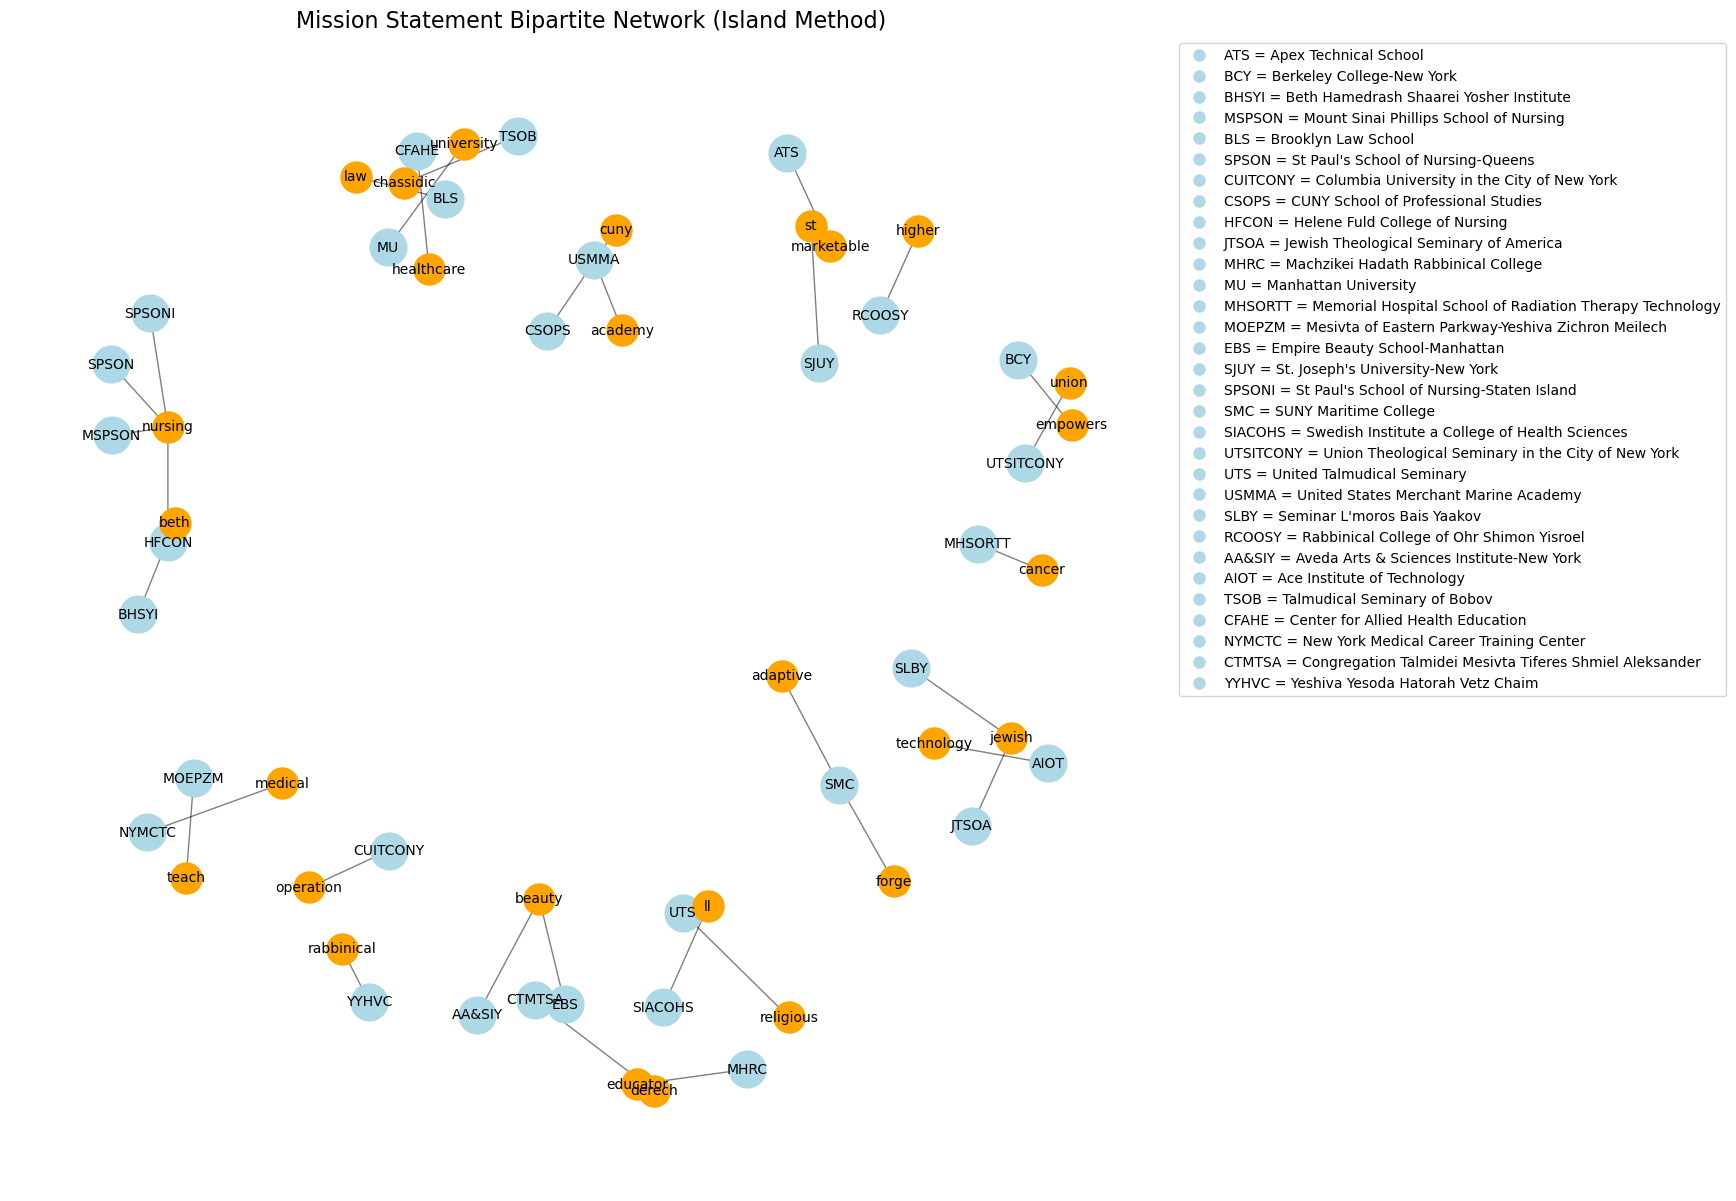

In [22]:
# Module 12: Visualize Network with Abbreviated Names for Institutions and Full Names in Legend (Modified)

import matplotlib.pyplot as plt

# Check if the graph is empty
if len(Gt.nodes()) > 0:
    # Increase figure size for better readability
    plt.figure(figsize=(15, 15))  # Adjust width and height to make the plot larger
    
    # Compute layout only for nodes that exist in Gt
    pos = nx.spring_layout(Gt, seed=42, k=0.3, iterations=50)  # Increased 'k' value for more space between nodes
    
    # Extract node types ONLY from Gt
    institutions = [n for n, d in Gt.nodes(data=True) if d.get("bipartite") == "institution"]
    keywords = [n for n, d in Gt.nodes(data=True) if d.get("bipartite") == "keyword"]

    # Abbreviate all institution names by taking the first letter of each word
    abbreviated_institutions = {}
    for inst in institutions:
        abbreviation = ''.join([word[0].upper() for word in inst.split() if word])  # Take first letter of each word
        abbreviated_institutions[inst] = abbreviation

    # Draw nodes for institutions
    nx.draw_networkx_nodes(Gt, pos, nodelist=institutions,
                           node_color="lightblue", node_size=700, label="Institution")

    # Draw nodes for keywords
    nx.draw_networkx_nodes(Gt, pos, nodelist=keywords,
                           node_color="orange", node_size=500, label="Mission Keyword")

    # Draw edges
    nx.draw_networkx_edges(Gt, pos, alpha=0.5)

    # Draw abbreviated labels for institutions
    nx.draw_networkx_labels(Gt, pos, labels=abbreviated_institutions, font_size=10)

    # Draw full labels for keywords
    keyword_labels = {keyword: keyword for keyword in keywords}
    nx.draw_networkx_labels(Gt, pos, labels=keyword_labels, font_size=10, font_color="black")

    # Add custom legend with full names for institutions
    custom_labels = [f"{abbr} = {full_name}" for full_name, abbr in abbreviated_institutions.items()]
    
    # Creating custom handles for the legend (one for each institution)
    custom_handles = [plt.Line2D([0], [0], marker='o', color='w', label=label, markersize=10, markerfacecolor='lightblue') 
                      for label in custom_labels]
    
    # Display the custom legend on the right side
    plt.legend(custom_handles, custom_labels, loc="upper left", bbox_to_anchor=(1, 1))

    # Title and cleanup
    plt.title("Mission Statement Bipartite Network (Island Method)", fontsize=16)
    plt.axis("off")  # Turn off axis for a cleaner look
    plt.show()

else:
    print("The graph is empty. No nodes to visualize.")